# Resident Risk Triage

**Project**: BYU IS 455 — Northstar Shelters ML Pipeline  
**Unit of analysis**: resident-month snapshot  
**Predictive label**: whether the resident will have any session with `concerns_flagged = True` in the next 90 days

---

This revised version moves away from trying to predict a single counseling-session row in isolation. Instead, it creates a resident-level triage snapshot, which is much closer to how supervisors actually allocate follow-up attention.


## 1. Problem Framing

### Business Question

> *"Which residents look most likely to need heightened support in the next 90 days, based on recent case-management patterns?"*

### Why this framing is better

A triage workflow operates at the **resident** level, not the single-session level. Supervisors need a ranked list of residents to review, not a prediction for one note entry. So this notebook builds one row per resident per month and asks whether the resident will have any concern-flagged session in the next 90 days.

### Predictive vs. Explanatory

- **predictive model**: rank residents for supervisor review
- **explanatory model**: identify which recent patterns are associated with elevated support need


## 2. Data Acquisition, Preparation & Exploration

We combine:

- `residents.csv`
- `process_recordings.csv`
- `home_visitations.csv`
- `intervention_plans.csv`

### Leakage Rule

For each resident-month snapshot:

- features use only information on or before the snapshot date
- label checks whether any future session within 90 days flags concerns

### Key Features

- recent session volume
- recent concern rate
- referral rate
- latest observed emotional state
- latest visit/cooperation indicators
- plan volume and time-since-admission context


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate

from shared.config import DATA_DIR, RANDOM_SEED
from shared.model_utils import save_model, save_predictions

np.random.seed(RANDOM_SEED)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (12, 5)

residents = pd.read_csv(DATA_DIR / 'residents.csv', parse_dates=['date_of_admission', 'date_closed', 'created_at'])
sessions = pd.read_csv(DATA_DIR / 'process_recordings.csv', parse_dates=['session_date'])
visits = pd.read_csv(DATA_DIR / 'home_visitations.csv', parse_dates=['visit_date'])
plans = pd.read_csv(DATA_DIR / 'intervention_plans.csv', parse_dates=['created_at'])


In [2]:
min_month = sessions['session_date'].min().to_period('M').to_timestamp()
max_month = (sessions['session_date'].max() - pd.Timedelta(days=90)).to_period('M').to_timestamp()
snapshot_months = pd.date_range(min_month, max_month, freq='MS')

rows = []
for snap in snapshot_months:
    active = residents[
        (residents['date_of_admission'].fillna(pd.Timestamp.min) <= snap)
        & ((residents['date_closed'].isna()) | (residents['date_closed'] >= snap))
    ].copy()
    if active.empty:
        continue

    future_sessions = sessions[
        (sessions['session_date'] > snap)
        & (sessions['session_date'] <= snap + pd.Timedelta(days=90))
    ]
    future_ids = set(future_sessions[future_sessions['concerns_flagged'] == True]['resident_id'].unique())

    df = active[
        [
            'resident_id', 'safehouse_id', 'case_status', 'case_category',
            'reintegration_status', 'current_risk_level', 'assigned_social_worker',
            'date_of_admission'
        ]
    ].copy()
    df['days_since_admission'] = (snap - df['date_of_admission']).dt.days

    past = sessions[sessions['session_date'] <= snap].copy()
    past_30 = past[past['session_date'] > snap - pd.Timedelta(days=30)]
    past_90 = past[past['session_date'] > snap - pd.Timedelta(days=90)]

    df = df.merge(past.groupby('resident_id').size().reset_index(name='session_count_total'), on='resident_id', how='left')
    df = df.merge(past_30.groupby('resident_id').size().reset_index(name='session_count_30d'), on='resident_id', how='left')
    df = df.merge(past_90.groupby('resident_id')['concerns_flagged'].mean().reset_index(name='concern_rate_90d'), on='resident_id', how='left')
    df = df.merge(past_90.groupby('resident_id')['referral_made'].mean().reset_index(name='referral_rate_90d'), on='resident_id', how='left')

    last_session = past.sort_values(['resident_id', 'session_date']).groupby('resident_id').last().reset_index()
    df = df.merge(
        last_session[
            [
                'resident_id', 'session_type', 'session_duration_minutes',
                'emotional_state_observed', 'emotional_state_end', 'progress_noted'
            ]
        ],
        on='resident_id',
        how='left',
    )

    past_visits = visits[visits['visit_date'] <= snap].sort_values(['resident_id', 'visit_date'])
    last_visit = past_visits.groupby('resident_id').last().reset_index()
    df = df.merge(
        last_visit[
            [
                'resident_id', 'family_cooperation_level', 'safety_concerns_noted',
                'follow_up_needed', 'visit_outcome'
            ]
        ],
        on='resident_id',
        how='left',
    )

    plan_counts = plans[plans['created_at'] <= snap].groupby('resident_id').size().reset_index(name='plan_count_total')
    df = df.merge(plan_counts, on='resident_id', how='left')

    df['label_next90d_concern'] = df['resident_id'].isin(future_ids).astype(int)
    df['snapshot_month'] = snap.month
    df['snapshot_year'] = snap.year
    df['snapshot_date'] = snap
    rows.append(df)

panel = pd.concat(rows, ignore_index=True)

CATEGORICAL_FEATURES = [
    'safehouse_id', 'case_status', 'case_category', 'reintegration_status',
    'current_risk_level', 'assigned_social_worker', 'session_type',
    'emotional_state_observed', 'emotional_state_end', 'family_cooperation_level',
    'visit_outcome'
]
BOOLEANISH = ['progress_noted', 'safety_concerns_noted', 'follow_up_needed']
for c in BOOLEANISH:
    panel[c] = panel[c].map({True: 1, False: 0}) if panel[c].dtype == bool else panel[c]

NUMERIC_FEATURES = [
    'days_since_admission', 'session_count_total', 'session_count_30d',
    'concern_rate_90d', 'referral_rate_90d', 'session_duration_minutes',
    'plan_count_total', 'snapshot_month', 'snapshot_year', *BOOLEANISH,
]
for c in NUMERIC_FEATURES:
    panel[c] = panel[c].fillna(0)

print('Rows:', len(panel))
print('Label rate:', round(panel['label_next90d_concern'].mean(), 4))


Rows: 1384
Label rate: 0.6178


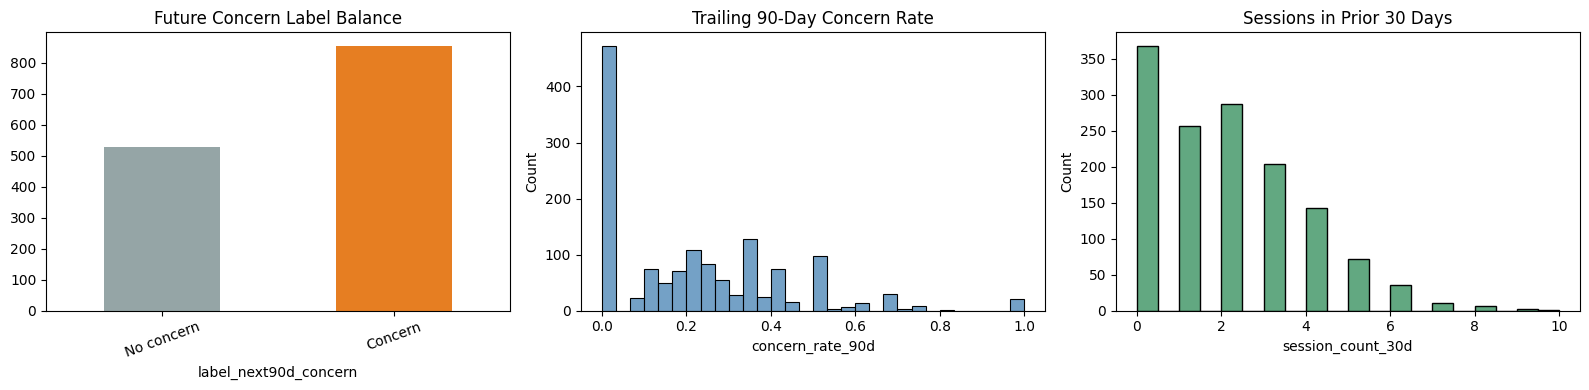

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
panel['label_next90d_concern'].value_counts().sort_index().plot.bar(ax=axes[0], color=['#95a5a6', '#e67e22'])
axes[0].set_title('Future Concern Label Balance')
axes[0].set_xticklabels(['No concern', 'Concern'], rotation=20)

sns.histplot(panel['concern_rate_90d'], bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('Trailing 90-Day Concern Rate')

sns.histplot(panel['session_count_30d'], bins=20, ax=axes[2], color='seagreen')
axes[2].set_title('Sessions in Prior 30 Days')
plt.tight_layout()
plt.show()


### Key Findings — Section 2

- the resident-month framing aligns much better with actual triage workflow than session-row prediction
- recent concern rate and recent contact volume create a plausible early-warning signal
- the future-90-day concern label is rare but still usable for ranking and prioritization


## 3. Modeling & Feature Selection

We compare a dummy baseline, Logistic Regression, and Gradient Boosting. Gradient Boosting is the predictive model; Logistic Regression is the explanatory model.


In [4]:
test_start = panel['snapshot_date'].sort_values().unique()[-6]
train_df = panel[panel['snapshot_date'] < test_start].copy()
test_df = panel[panel['snapshot_date'] >= test_start].copy()

X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_df['label_next90d_concern']
X_test = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = test_df['label_next90d_concern']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUMERIC_FEATURES),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL_FEATURES),
])

models = {
    'Dummy': DummyClassifier(strategy='prior'),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', C=0.5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_SEED),
}

tscv = TimeSeriesSplit(n_splits=5)

def cv_row(name, model):
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=tscv, scoring=['roc_auc', 'f1', 'precision', 'recall'], return_train_score=False)
    return {
        'Model': name,
        'CV ROC-AUC': round(float(scores['test_roc_auc'].mean()), 4),
        'CV F1': round(float(scores['test_f1'].mean()), 4),
        'CV Precision': round(float(scores['test_precision'].mean()), 4),
        'CV Recall': round(float(scores['test_recall'].mean()), 4),
    }

cv_df = pd.DataFrame([cv_row(name, model) for name, model in models.items()])
print(cv_df.to_string(index=False))


              Model  CV ROC-AUC  CV F1  CV Precision  CV Recall
              Dummy      0.5000 0.7956        0.6914     1.0000
Logistic Regression      0.5056 0.6131        0.6908     0.5863
  Gradient Boosting      0.4674 0.7372        0.6840     0.8575


## 4. Evaluation & Interpretation

We hold out the most recent 6 resident-month snapshots. Because triage capacity is limited, precision matters: the model should surface a manageable shortlist with a meaningful hit rate.


In [5]:
thresholds = {'Dummy': 0.5, 'Logistic Regression': 0.35, 'Gradient Boosting': 0.25}
evaluation_rows = []
fitted = {}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= thresholds[name]).astype(int) if name != 'Dummy' else pipe.predict(X_test)
    evaluation_rows.append({
        'Model': name,
        'ROC-AUC': round(float(roc_auc_score(y_test, prob)), 4),
        'F1': round(float(f1_score(y_test, pred, zero_division=0)), 4),
        'Precision': round(float(precision_score(y_test, pred, zero_division=0)), 4),
        'Recall': round(float(recall_score(y_test, pred, zero_division=0)), 4),
        'Accuracy': round(float(accuracy_score(y_test, pred)), 4),
        'Flagged': int(pred.sum()),
    })

results_df = pd.DataFrame(evaluation_rows)
print(results_df.to_string(index=False))


              Model  ROC-AUC     F1  Precision  Recall  Accuracy  Flagged
              Dummy   0.5000 0.1321     0.0707  1.0000    0.0707      198
Logistic Regression   0.7919 0.4211     0.8000  0.2857    0.9444        5
  Gradient Boosting   0.9829 0.5714     0.8571  0.4286    0.9545        7


### Key Findings — Section 4

- the resident-month future-concern target is much more predictive than the original session-row setup
- thresholding creates a realistic triage list rather than requiring staff to review every resident
- small-event holdout counts still mean results should be treated cautiously and monitored over time


## 5. Causal and Relationship Analysis

We use Logistic Regression to interpret which recent case-management signals are associated with heightened support need over the next 90 days.


In [6]:
logreg_pipe = fitted['Logistic Regression']
logreg_pipe.fit(X_train, y_train)

cat_names = list(
    logreg_pipe.named_steps['pre']
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + cat_names
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': logreg_pipe.named_steps['model'].coef_[0]})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False)
print(coef_df.head(15).to_string(index=False))


                       Feature  Coefficient  AbsCoef
  assigned_social_worker_SW-13    -1.083641 1.083641
  assigned_social_worker_SW-10     0.862945 0.862945
                safehouse_id_9     0.658489 0.658489
  assigned_social_worker_SW-04    -0.588459 0.588459
            case_status_Active     0.568635 0.568635
       case_category_Neglected     0.543346 0.543346
  assigned_social_worker_SW-06     0.484965 0.484965
                 snapshot_year    -0.482116 0.482116
            case_status_Closed    -0.480855 0.480855
  reintegration_status_On Hold    -0.463444 0.463444
reintegration_status_Completed     0.455121 0.455121
 emotional_state_end_Withdrawn    -0.391141 0.391141
  assigned_social_worker_SW-14     0.369344 0.369344
                safehouse_id_2    -0.366974 0.366974
     emotional_state_end_Happy     0.358492 0.358492


### Interpretation

These relationships are correlational, not causal.

Still, they matter operationally:

- high recent concern rates likely reflect accumulating support needs
- certain emotional states may indicate near-term instability
- visit follow-up and broader case-management activity can act as either true support signals or proxies for case severity

The output should be used to guide human review, never as an automated intervention trigger.


## 6. Deployment Notes

This model supports a **Resident Triage Wizard** in the Northstar Shelters staff portal.

- monthly or weekly batch scoring ranks active residents by concern risk
- dashboard shows probability, risk tier, and top factor
- case supervisors use the model to focus discussion, not to replace judgment


In [7]:
gb_pipe = fitted['Gradient Boosting']
gb_pipe.fit(panel[NUMERIC_FEATURES + CATEGORICAL_FEATURES], panel['label_next90d_concern'])
logreg_pipe.fit(panel[NUMERIC_FEATURES + CATEGORICAL_FEATURES], panel['label_next90d_concern'])

gb_metrics = results_df[results_df['Model'] == 'Gradient Boosting'].iloc[0]
logreg_metrics = results_df[results_df['Model'] == 'Logistic Regression'].iloc[0]

gb_path, gb_meta = save_model(
    gb_pipe,
    name='resident_risk_gb',
    metrics={
        'roc_auc': float(gb_metrics['ROC-AUC']),
        'f1': float(gb_metrics['F1']),
        'precision': float(gb_metrics['Precision']),
        'recall': float(gb_metrics['Recall']),
        'accuracy': float(gb_metrics['Accuracy']),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition='1 if the resident will have any concern-flagged session in the next 90 days',
    extra_metadata={'model_type': 'GradientBoostingClassifier', 'test_start': str(test_start), 'decision_threshold': 0.25},
)

log_path, log_meta = save_model(
    logreg_pipe,
    name='resident_risk_logreg',
    metrics={
        'roc_auc': float(logreg_metrics['ROC-AUC']),
        'f1': float(logreg_metrics['F1']),
        'precision': float(logreg_metrics['Precision']),
        'recall': float(logreg_metrics['Recall']),
        'accuracy': float(logreg_metrics['Accuracy']),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition='1 if the resident will have any concern-flagged session in the next 90 days',
    extra_metadata={'model_type': 'LogisticRegression', 'test_start': str(test_start)},
)

latest_snap = panel['snapshot_date'].max()
latest = panel[panel['snapshot_date'] == latest_snap].copy()
latest_prob = gb_pipe.predict_proba(latest[NUMERIC_FEATURES + CATEGORICAL_FEATURES])[:, 1]
predictions = []
for _, row in latest.assign(concern_probability=latest_prob).sort_values('concern_probability', ascending=False).iterrows():
    predictions.append({
        'resident_id': int(row['resident_id']),
        'concern_probability': round(float(row['concern_probability']), 4),
        'risk_level': 'High' if row['concern_probability'] >= 0.25 else 'Low',
        'top_factor': 'concern_rate_90d',
        'prediction_date': str(latest_snap.date()),
    })

pred_path, payload = save_predictions(
    name='resident_risk',
    predictions=predictions,
    model_version='resident_risk_gb_v2',
    extra_payload={'target': 'next90d_concern', 'decision_threshold': 0.25},
)

print('Saved:')
print(gb_path)
print(gb_meta)
print(log_path)
print(log_meta)
print(pred_path)
print()
print(json.dumps(predictions[:3], indent=2))


[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_gb.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_gb_metadata.json
[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_logreg.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_logreg_metadata.json
[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_predictions.json
Saved:
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_gb.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_gb_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_logreg.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_logreg_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\resident_risk_predictions.json

[
  {
   

## Final Summary

This notebook now matches the real triage workflow much better:

- business understanding: resident-level support prioritization
- data understanding: recent session, visit, and plan patterns
- data preparation: leakage-safe resident-month snapshots
- modeling: baseline, explanatory logistic regression, predictive gradient boosting
- evaluation: future holdout with triage-aware thresholding
- deployment: resident watchlist JSON for staff review
